# **Statistical Analysis: B-cos**

**Authors:** Katrine Bjerre (katbj@itu.dk) & Kristine Emilie Risager Pedersen (krep@itu.dk)

Last edited: 22.04.2026

## **Table of Contents**

1. [Helper Functions](#helper-functions)
2. [Experiment: Generalised LOTO](#experiment-generalized-loto)
3. [Experiment: Subject-Specific Scratch](#experiment-subject-specific-scratch)
4. [Experiment: Subject-Specific Transfer (Last Two Conv)](#experiment-subject-specific-transfer-last-two-conv)
5. [Experiment Comparison](#experiment-comparison)

## **Helper Functions**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({"text.usetex": False, 
                     "font.family": "serif", 
                     "mathtext.fontset": "cm", 
                     "font.size": 14, 
                     "axes.labelsize": 15, 
                     "axes.titlesize": 16, 
                     "xtick.labelsize": 13, 
                     "ytick.labelsize": 13, 
                     }
                    )


def load_results(csv_path):
    """
    Load CSV file into a DataFrame and print basic info.
    """
    df = pd.read_csv(csv_path)
    print(f"Loaded: {csv_path}")
    print(f"Models found: {df['model_name'].nunique()}")
    return df

# ==================== PLOTS ====================

def plot_model_performance(df, experiment_name, error_col="test_ang_error"):
    """
    Bar plot of test angular error.
    """
    plt.figure(figsize=(12, 10))
    plt.bar(df["model_name"], df[error_col])

    #plt.title(f"{experiment_name} - Per-model Test Angular Error")
    plt.xlabel("Model")
    plt.ylabel("Test Angular Error")

    plt.xticks(rotation=90)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_error_distribution(df, experiment_name, error_col="test_ang_error"):
    """
    Histogram of test angular error.
    """
    plt.figure(figsize=(8, 4))
    plt.hist(df[error_col], bins=15)

    plt.title(f"{experiment_name} - Test Angular Error")
    plt.xlabel("Test Angular Error")
    plt.ylabel("Count")

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ==================== SUBJECT SPEC ====================

def split_by_subject_spec_id(df):
    """
    Split dataframe into one dataframe per subject_spec_id.
    Returns: {subject_id: df_subject}
    """
    df = df.copy()
    df["subject_spec_id"] = df["subject_spec_id"].astype(str).str.zfill(3)

    dfs_by_subject = {}

    for subject_id in df["subject_spec_id"].unique():
        df_subject = df[df["subject_spec_id"] == subject_id]
        dfs_by_subject[subject_id] = df_subject

    return dfs_by_subject


def show_subject_specific_tables(df, experiment_name):
    """
    Show per-model test angular error separately for each subject.
    """
    dfs_by_subject = split_by_subject_spec_id(df)

    for subject_id, df_subject in dfs_by_subject.items():
        print(f"\n{experiment_name} - Subject {subject_id}")
        display(
            df_subject[["model_name", "subject_spec_id", "held_out_target", "test_ang_error"]]
            .sort_values(["subject_spec_id", "held_out_target"])
            .reset_index(drop=True)
        )


def plot_subject_specific_model_performance(df, experiment_name, error_col="test_ang_error"):
    """
    Plot per-model test angular error separately for each subject.
    """
    dfs_by_subject = split_by_subject_spec_id(df)

    for subject_id, df_subject in dfs_by_subject.items():
        experiment_name_subject = f"{experiment_name} - Subject {subject_id}"
        plot_model_performance(df_subject, experiment_name_subject, error_col=error_col)


def plot_subject_specific_error_distribution(df, experiment_name, error_col="test_ang_error"):
    """
    Plot test angular error distribution separately for each subject.
    """
    dfs_by_subject = split_by_subject_spec_id(df)

    for subject_id, df_subject in dfs_by_subject.items():
        experiment_name_subject = f"{experiment_name} - Subject {subject_id}"
        plot_error_distribution(df_subject, experiment_name_subject, error_col=error_col)


def plot_subject_specific_boxplots(df, experiment_name, error_col="test_ang_error"):
    """
    Boxplot of test angular error per subject for one experiment.
    """
    df = df.copy()
    df["subject_spec_id"] = df["subject_spec_id"].astype(str).str.zfill(3)

    plt.figure(figsize=(8, 5))
    df.boxplot(column=error_col, by="subject_spec_id")

    plt.title(f"Test Angular Error by Subject - {experiment_name}")
    plt.suptitle("")
    plt.xlabel("Subject")
    plt.ylabel("Test Angular Error")

    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

<br/>

## **Experiment: Generalized LOTO**

In [2]:
EXPERIMENT_NAME = "Generalized LOTO"
CSV_PATH = "../results/generalized_bcos/gen_loto_bcos.csv"

df_loto = load_results(CSV_PATH)
df_loto.head()

Loaded: ../results/generalized_bcos/gen_loto_bcos.csv
Models found: 25


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early
0,gen_loto_bcos_0,results\models\gen_loto_bcos_0.pth,NaN,general_loto_bcos,NaN,NaN,0,scratch,92562,1543,2316,38,2.279186,2.382934,2.382934,1470.887534,False
1,gen_loto_bcos_1,results\models\gen_loto_bcos_1.pth,NaN,general_loto_bcos,NaN,NaN,1,scratch,92574,1538,2309,13,3.279470,3.327747,3.327747,713.317545,True
2,gen_loto_bcos_2,results\models\gen_loto_bcos_2.pth,NaN,general_loto_bcos,NaN,NaN,2,scratch,92546,1550,2325,5,3.602421,3.503336,3.503336,426.297248,True
3,gen_loto_bcos_3,results\models\gen_loto_bcos_3.pth,NaN,general_loto_bcos,NaN,NaN,3,scratch,92556,1546,2319,23,2.063104,2.051302,2.051302,1070.417215,True
4,gen_loto_bcos_4,results\models\gen_loto_bcos_4.pth,NaN,general_loto_bcos,NaN,NaN,4,scratch,92521,1560,2340,24,2.708938,2.834560,2.834560,1106.079653,True


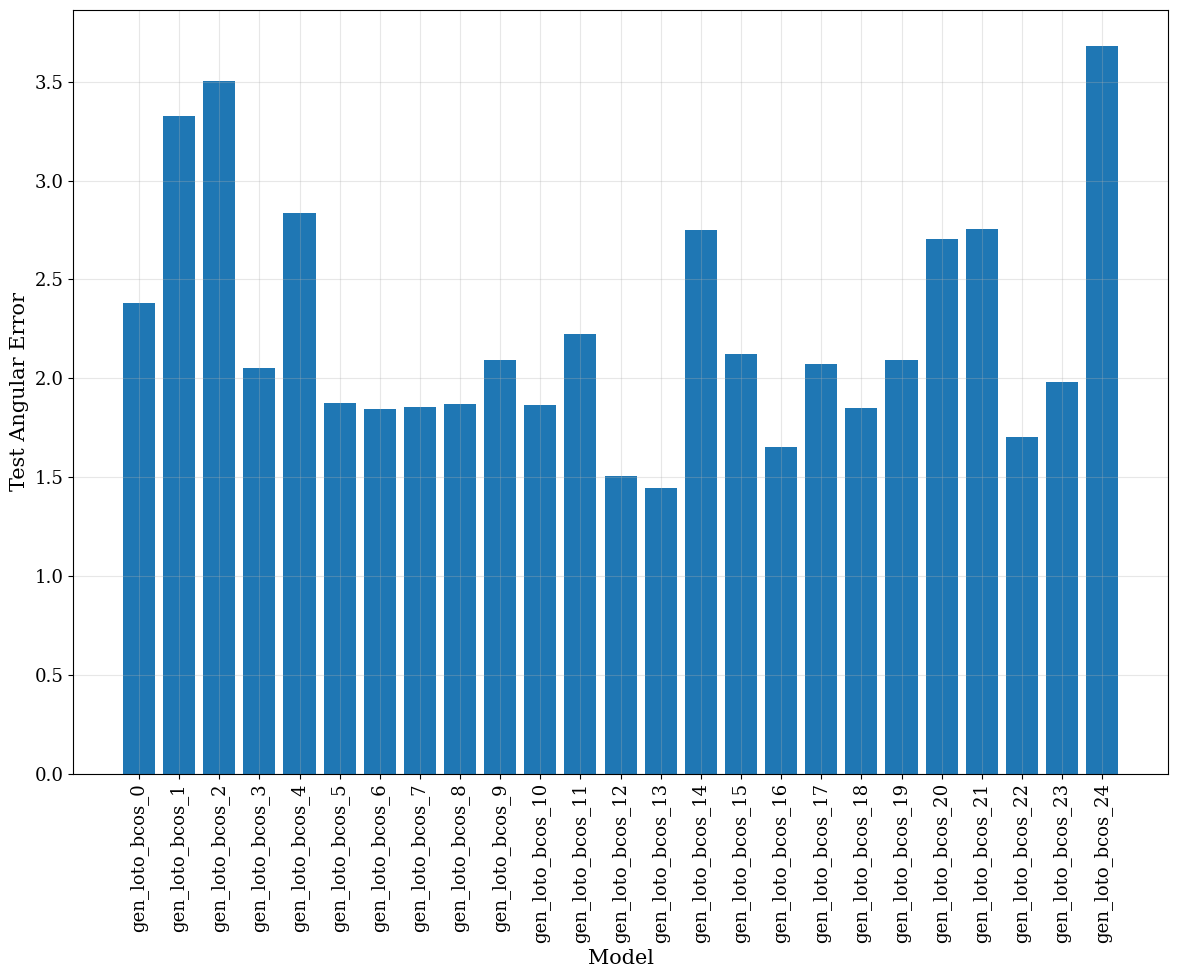

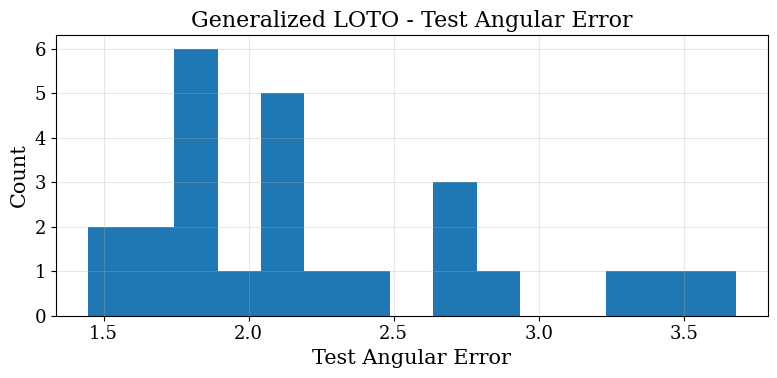

In [3]:
# print("Per-model test performance (Generalized LOTO):")
# display(
#     df_loto[["model_name", "held_out_target", "test_ang_error"]]
#     .sort_values("held_out_target")
#    .reset_index(drop=True)
# )

plot_model_performance(df_loto, EXPERIMENT_NAME)

plot_error_distribution(df_loto, EXPERIMENT_NAME)

<br/>

## **Experiment: Subject-Specific Scratch**

In [4]:
EXPERIMENT_NAME = "Subject-Specific Scratch"
CSV_PATH = "../results/subject_spec_bcos/subject_spec_scratch_bcos.csv"

df_scratch = load_results(CSV_PATH)
df_scratch.head()

Loaded: ../results/subject_spec_bcos/subject_spec_scratch_bcos.csv
Models found: 125


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early
0,subject_spec_scratch_bcos_002_0,results\models\subject_spec_scratch_bcos_002_0...,NaN,subject_spec_scratch_bcos,2,NaN,0,scratch,2270,38,59,10,16.428696,16.428928,16.428928,36.676133,True
1,subject_spec_scratch_bcos_002_1,results\models\subject_spec_scratch_bcos_002_1...,NaN,subject_spec_scratch_bcos,2,NaN,1,scratch,2270,38,59,2,6.997651,6.999731,6.999731,24.300061,True
2,subject_spec_scratch_bcos_002_2,results\models\subject_spec_scratch_bcos_002_2...,NaN,subject_spec_scratch_bcos,2,NaN,2,scratch,2275,36,56,22,0.987159,0.904067,0.904067,43.580828,True
3,subject_spec_scratch_bcos_002_3,results\models\subject_spec_scratch_bcos_002_3...,NaN,subject_spec_scratch_bcos,2,NaN,3,scratch,2270,38,59,4,11.175404,11.176040,11.176040,26.196560,True
4,subject_spec_scratch_bcos_002_4,results\models\subject_spec_scratch_bcos_002_4...,NaN,subject_spec_scratch_bcos,2,NaN,4,scratch,2270,38,59,6,15.518513,15.508479,15.508479,28.085287,True


### Combined Results

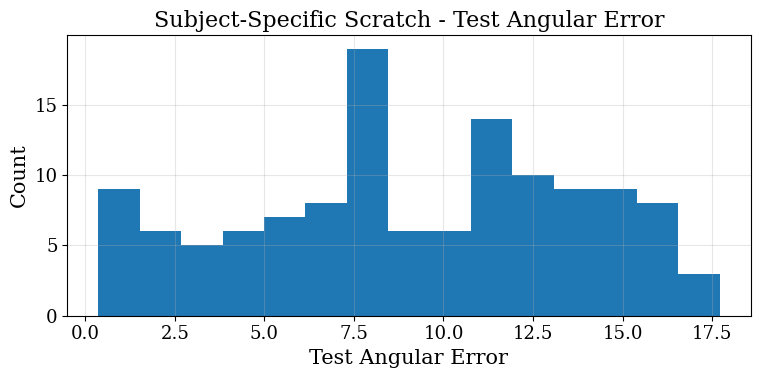

In [5]:
# print("Per-model test performance (Subject-Specific Scratch):")
# with pd.option_context("display.max_rows", None):
#     display(
#         df_scratch[["model_name", "subject_spec_id", "held_out_target", "test_ang_error"]]
#         .sort_values(["subject_spec_id","held_out_target"])
#         .reset_index(drop=True)
#     )

#Plot distribution of test angular error
plot_error_distribution(df_scratch, EXPERIMENT_NAME)

### Per-Subject Results

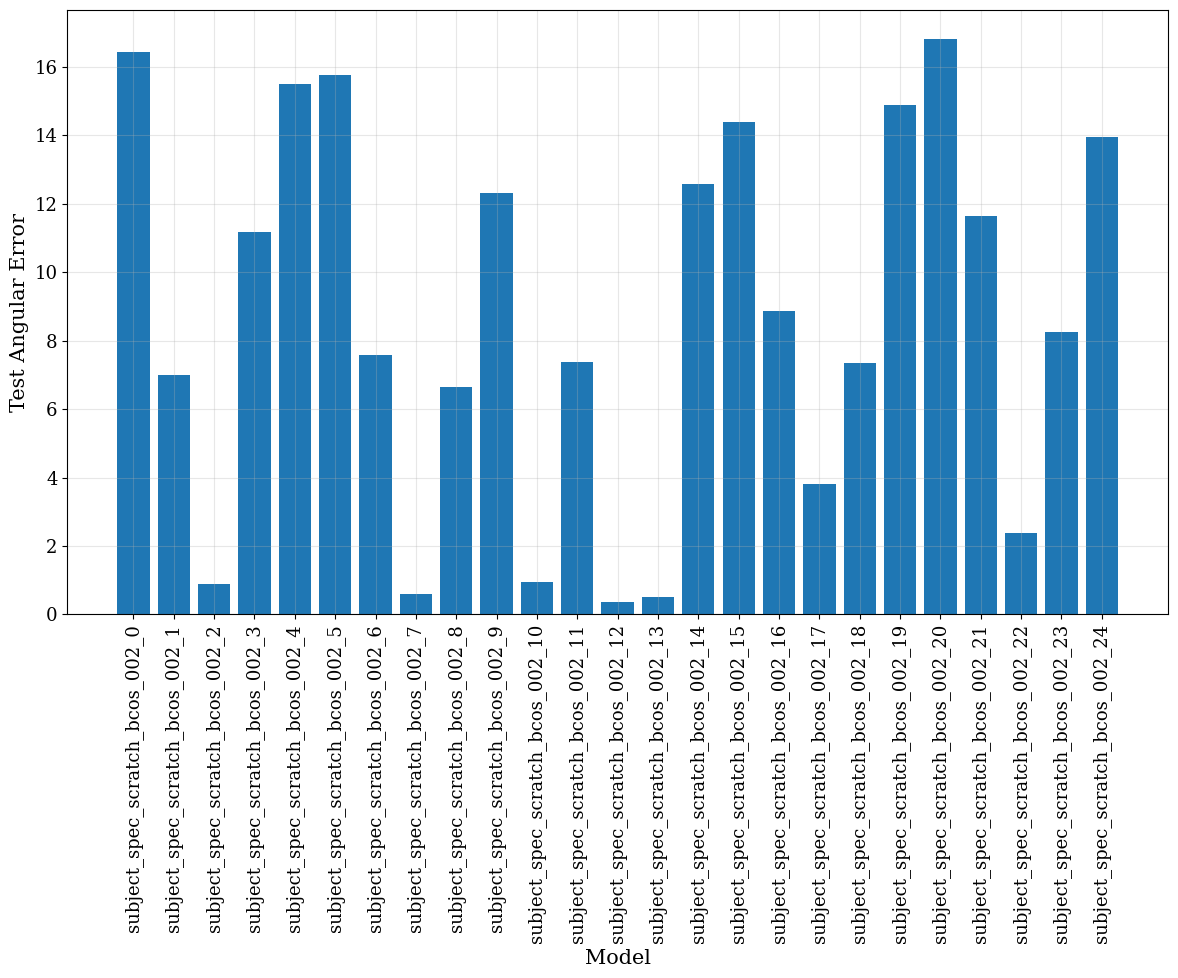

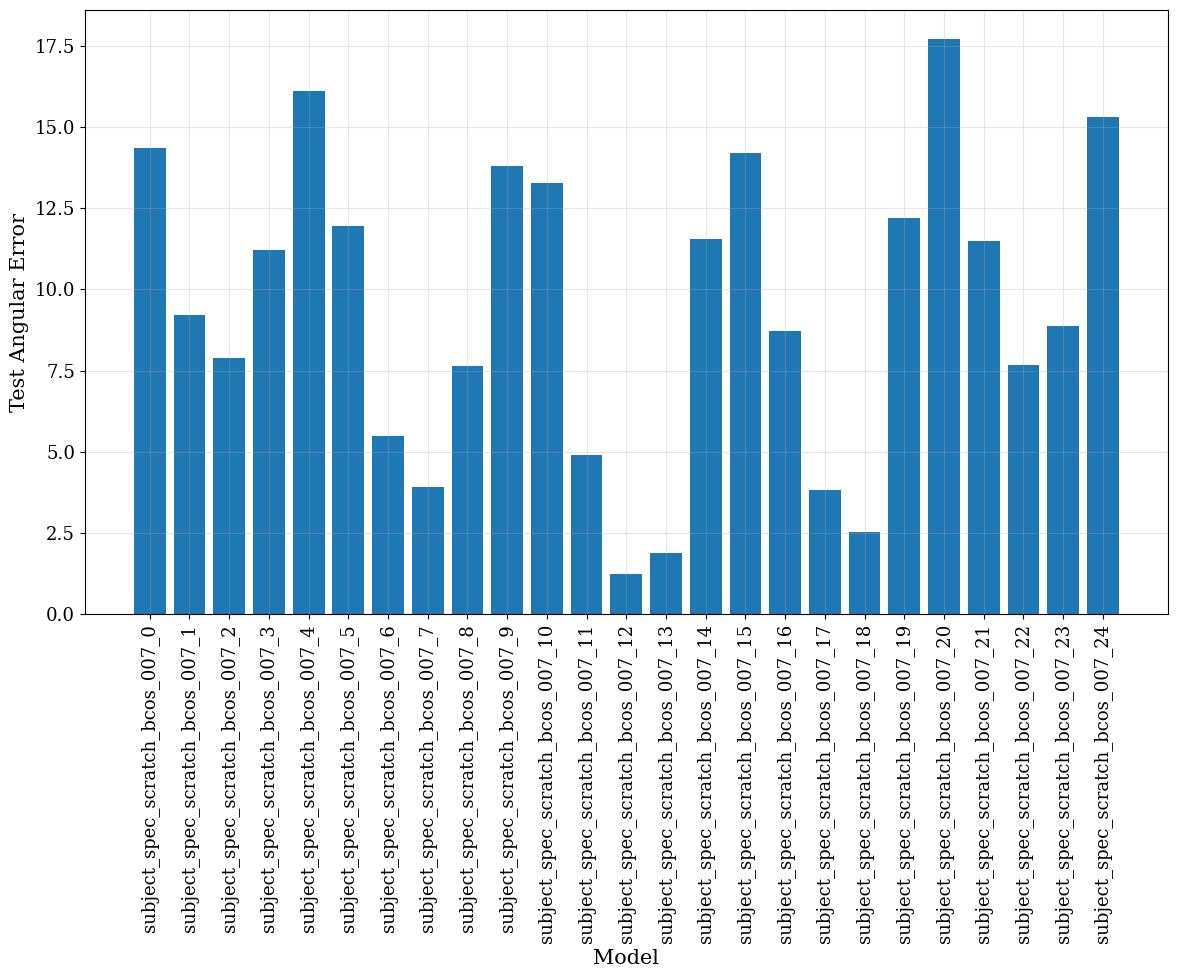

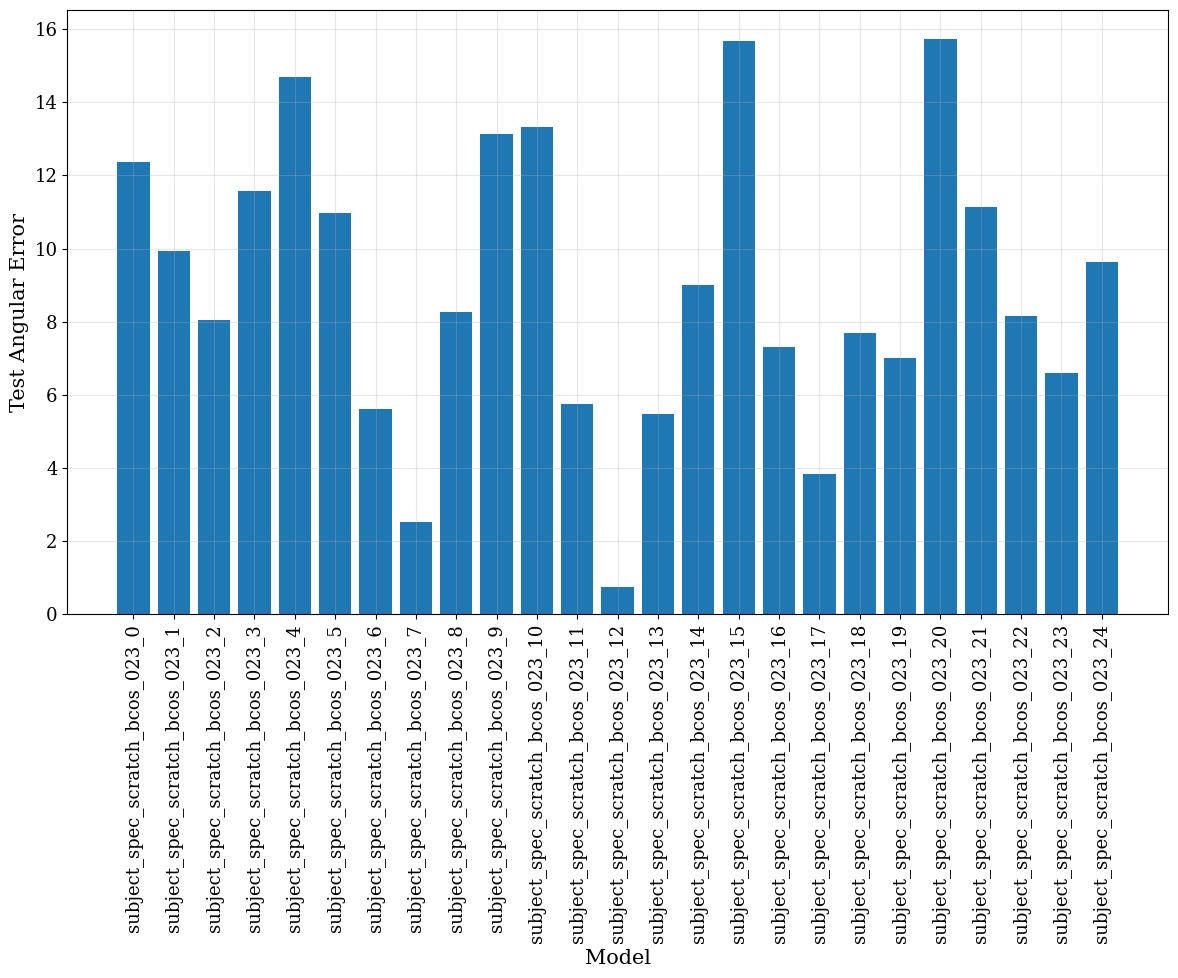

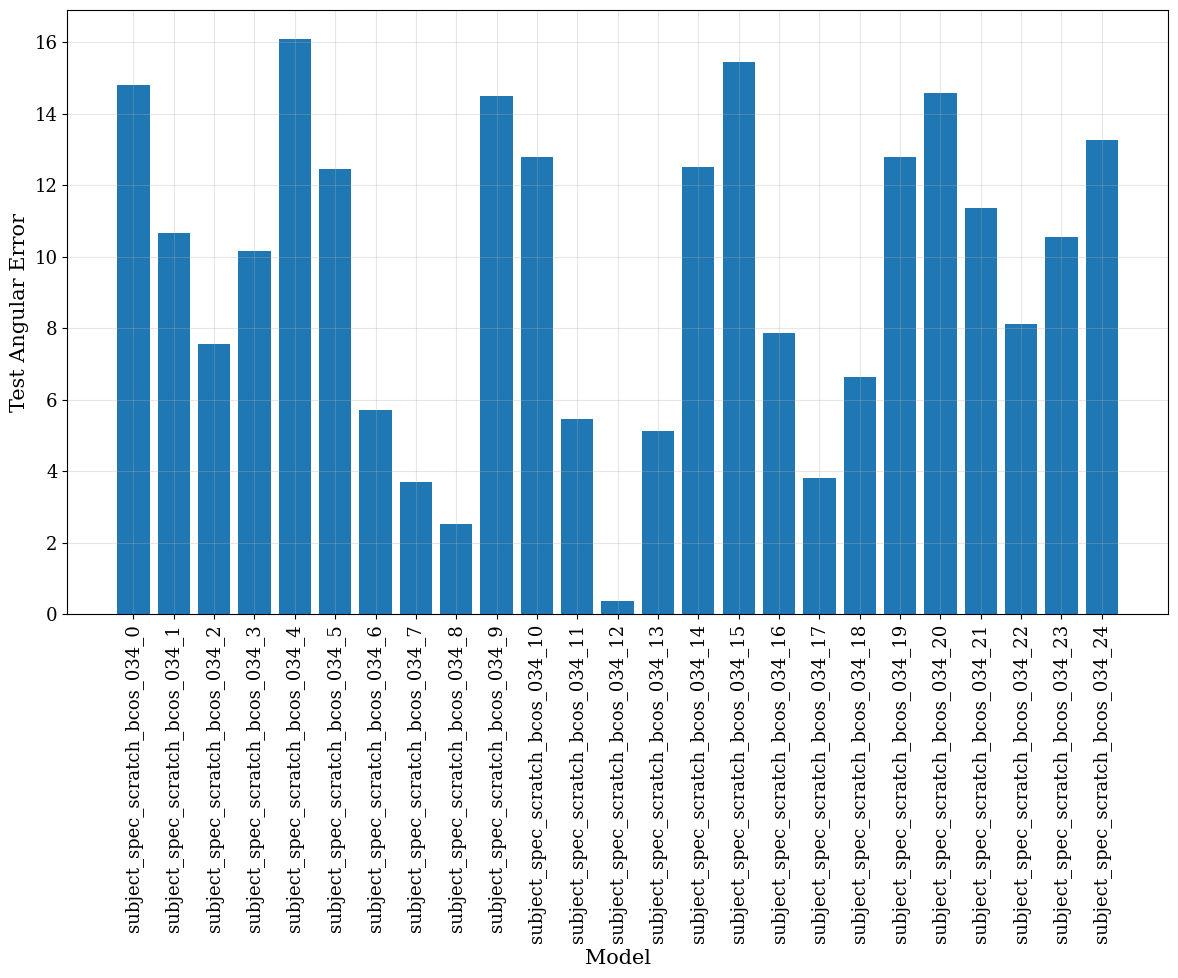

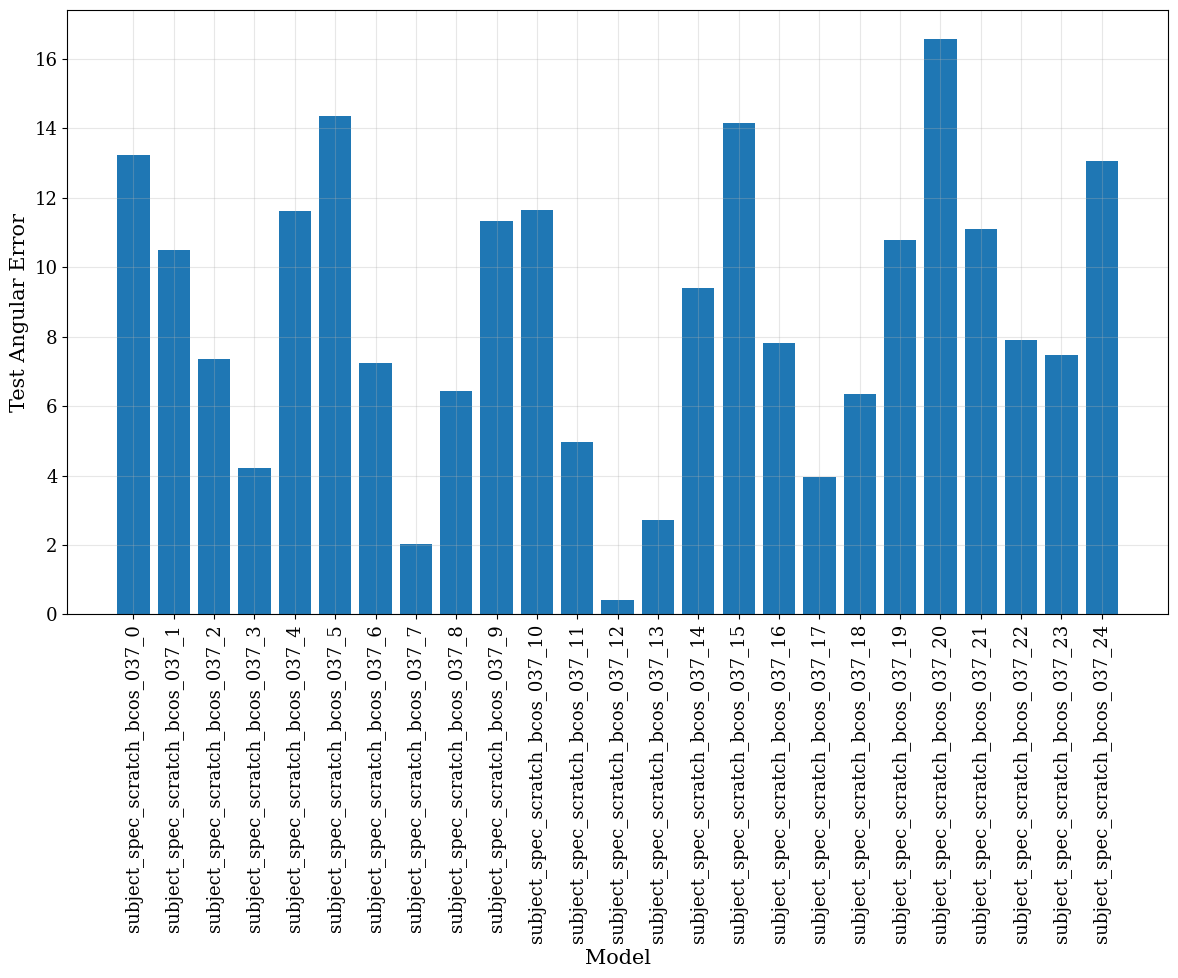

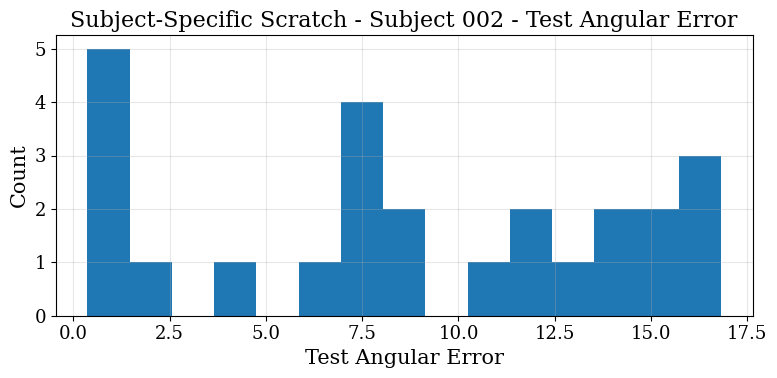

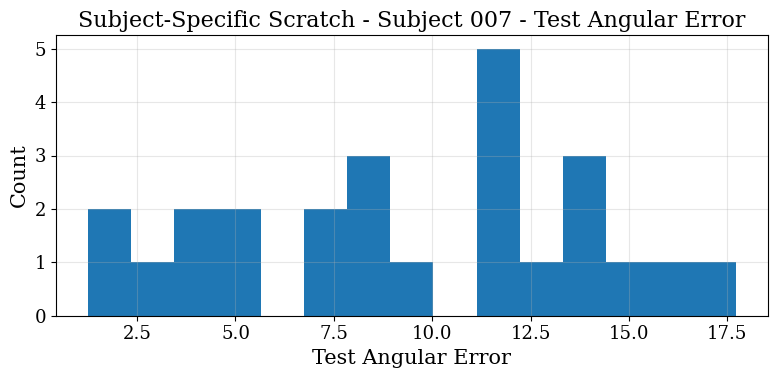

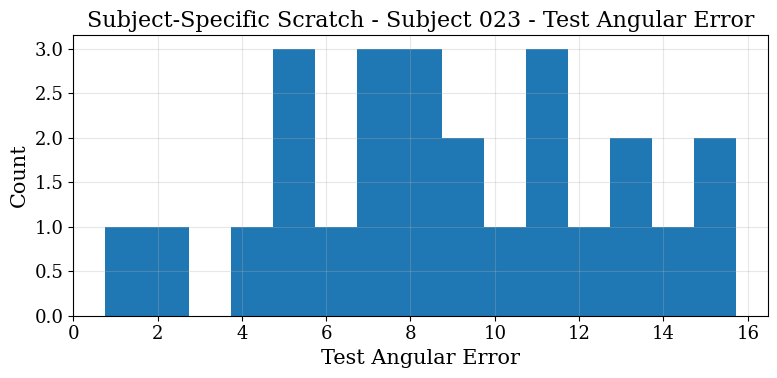

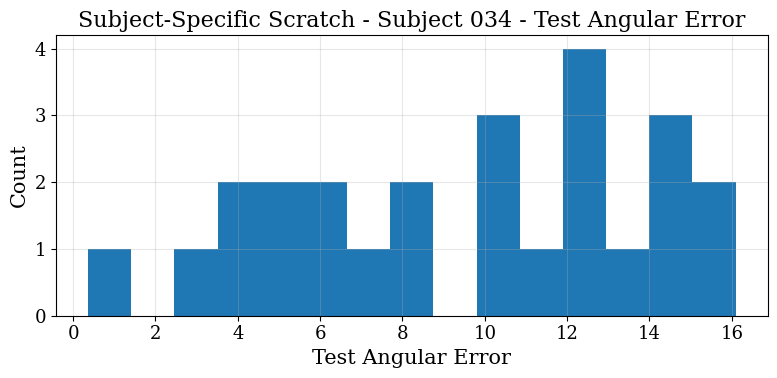

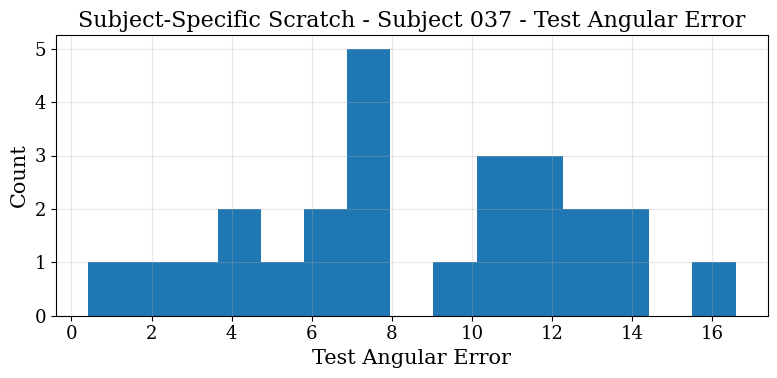

<Figure size 800x500 with 0 Axes>

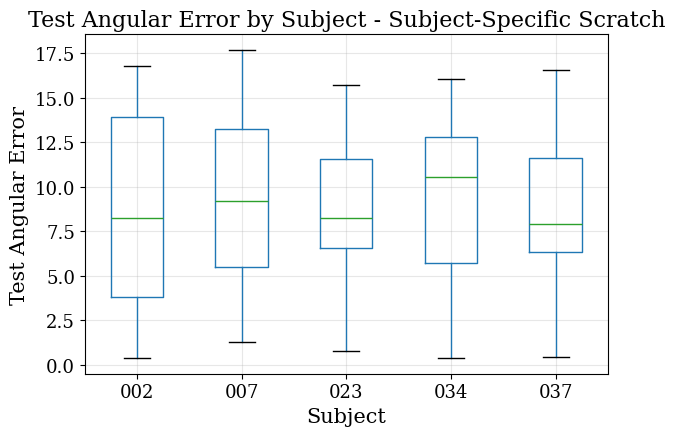

In [6]:
#show_subject_specific_tables(df_scratch, EXPERIMENT_NAME)
plot_subject_specific_model_performance(df_scratch, EXPERIMENT_NAME)
plot_subject_specific_error_distribution(df_scratch, EXPERIMENT_NAME)
plot_subject_specific_boxplots(df_scratch, EXPERIMENT_NAME)

<br/>

## **Experiment: Subject-Specific Transfer (Last Two Conv)**

In [7]:
EXPERIMENT_NAME = "Subject-Specific Transfer (Last Two Conv)"
CSV_PATH = "../results/subject_spec_bcos/subject_spec_transfer_last_two_conv_bcos.csv"

df_transfer_last_2_conv = load_results(CSV_PATH)
df_transfer_last_2_conv.head()

Loaded: ../results/subject_spec_bcos/subject_spec_transfer_last_two_conv_bcos.csv
Models found: 125


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,transfer_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early
0,subject_spec_transfer_last_two_conv_002_0_bcos,results\models\subject_spec_transfer_last_two_...,results\models\gen_loto_bcos_0.pth,subject_spec_transfer_bcos,2,NaN,0,transfer,last_two_conv,2270,38,59,10,0.371631,0.314788,0.314788,29.386061,True
1,subject_spec_transfer_last_two_conv_002_1_bcos,results\models\subject_spec_transfer_last_two_...,results\models\gen_loto_bcos_1.pth,subject_spec_transfer_bcos,2,NaN,1,transfer,last_two_conv,2270,38,59,13,0.887102,0.800854,0.800854,25.530676,True
2,subject_spec_transfer_last_two_conv_002_2_bcos,results\models\subject_spec_transfer_last_two_...,results\models\gen_loto_bcos_2.pth,subject_spec_transfer_bcos,2,NaN,2,transfer,last_two_conv,2275,36,56,16,1.136460,0.998220,0.998220,27.354430,True
3,subject_spec_transfer_last_two_conv_002_3_bcos,results\models\subject_spec_transfer_last_two_...,results\models\gen_loto_bcos_3.pth,subject_spec_transfer_bcos,2,NaN,3,transfer,last_two_conv,2270,38,59,10,0.596588,0.553700,0.553700,24.212602,True
4,subject_spec_transfer_last_two_conv_002_4_bcos,results\models\subject_spec_transfer_last_two_...,results\models\gen_loto_bcos_4.pth,subject_spec_transfer_bcos,2,NaN,4,transfer,last_two_conv,2270,38,59,7,0.726346,0.686144,0.686144,22.850135,True


### Combined Results

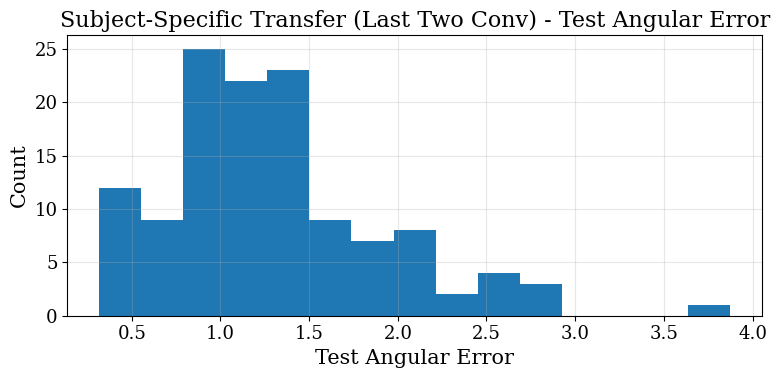

In [8]:
# print("Per-model test performance (Subject-Specific Transfer - Last Two Conv):")
# with pd.option_context("display.max_rows", None):
#     display(
#         df_transfer_last_2_conv[["model_name", "subject_spec_id", "held_out_target", "test_ang_error"]]
#         .sort_values("test_ang_error")
#         .reset_index(drop=True)
#     )

# Plot distribution of test angular error
plot_error_distribution(df_transfer_last_2_conv, EXPERIMENT_NAME)

### Per-Subject Results

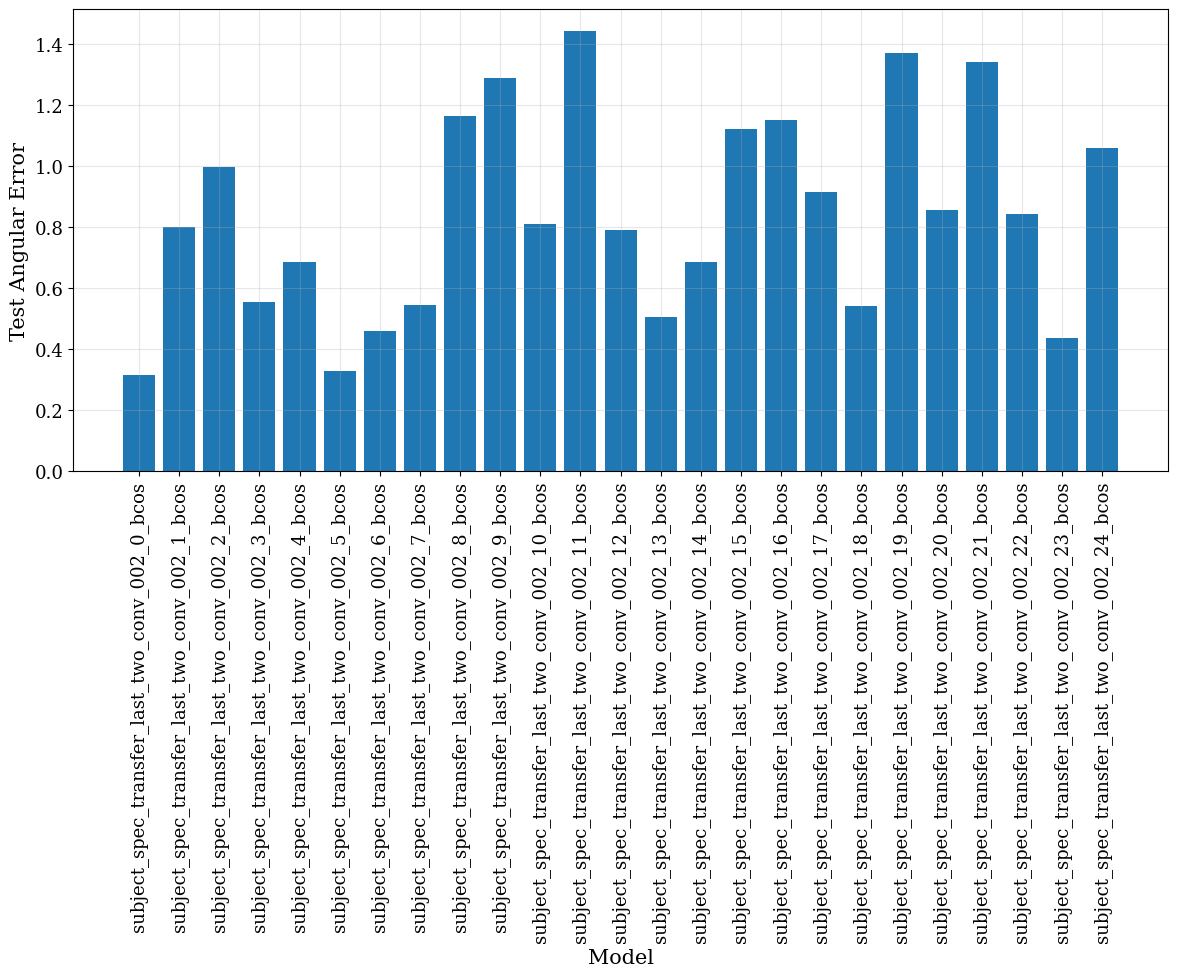

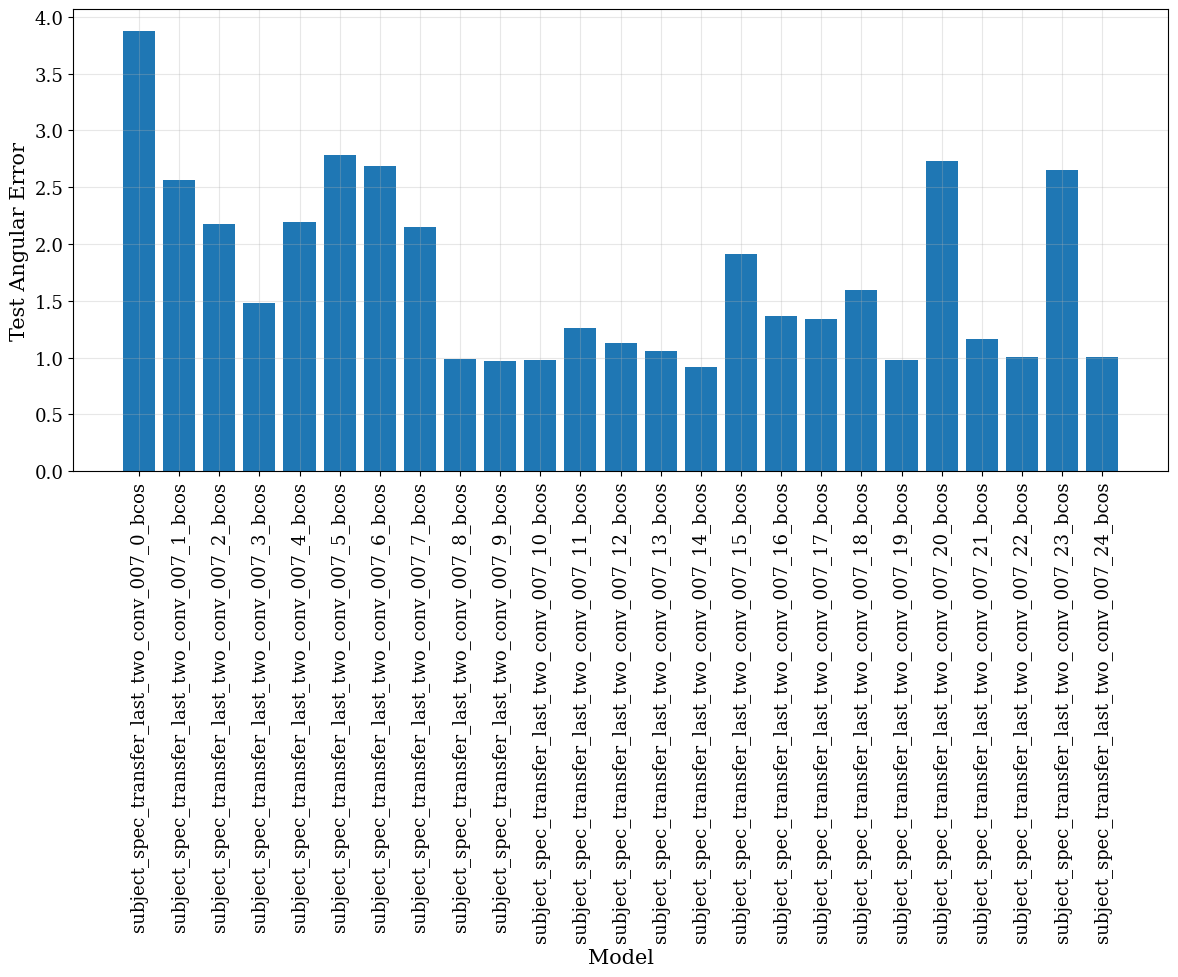

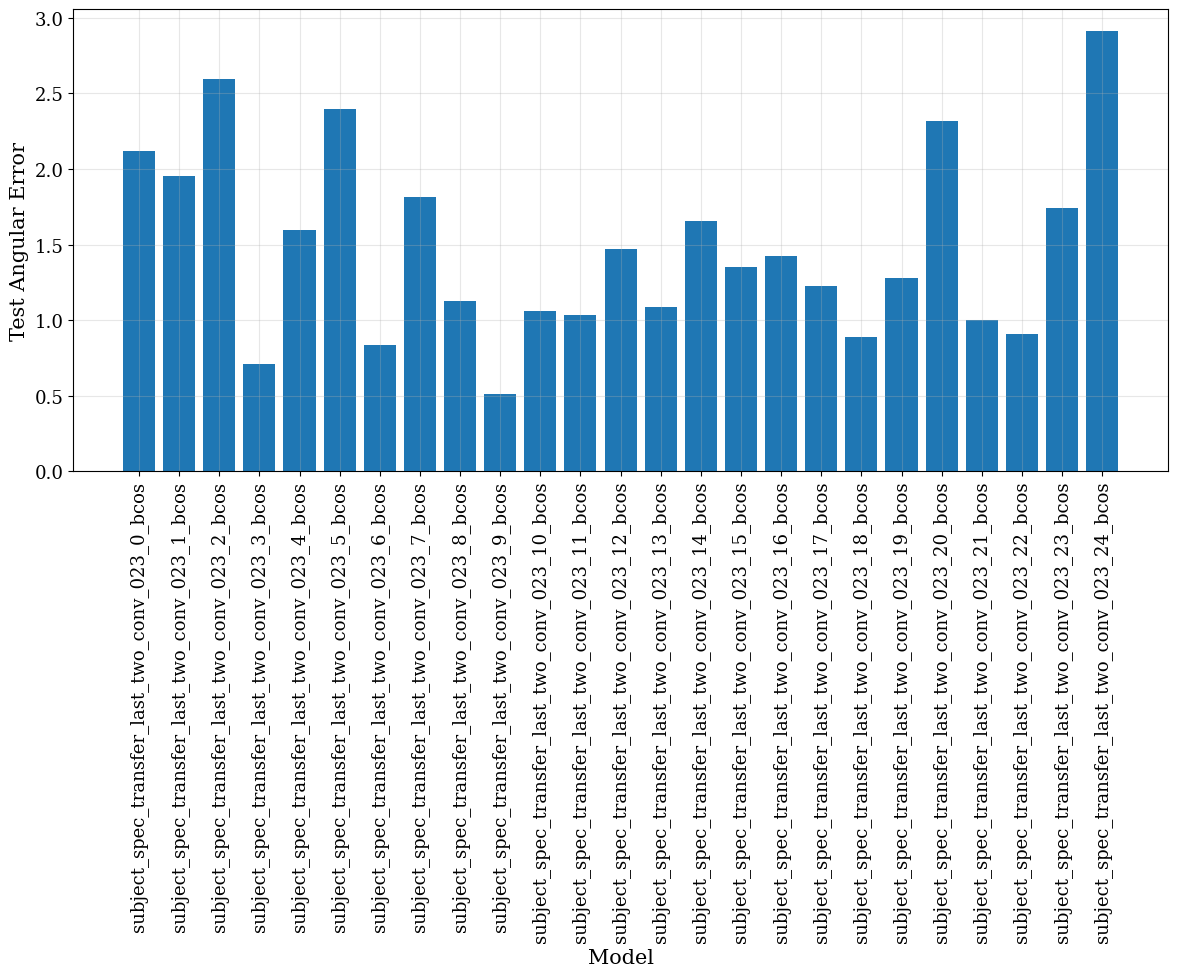

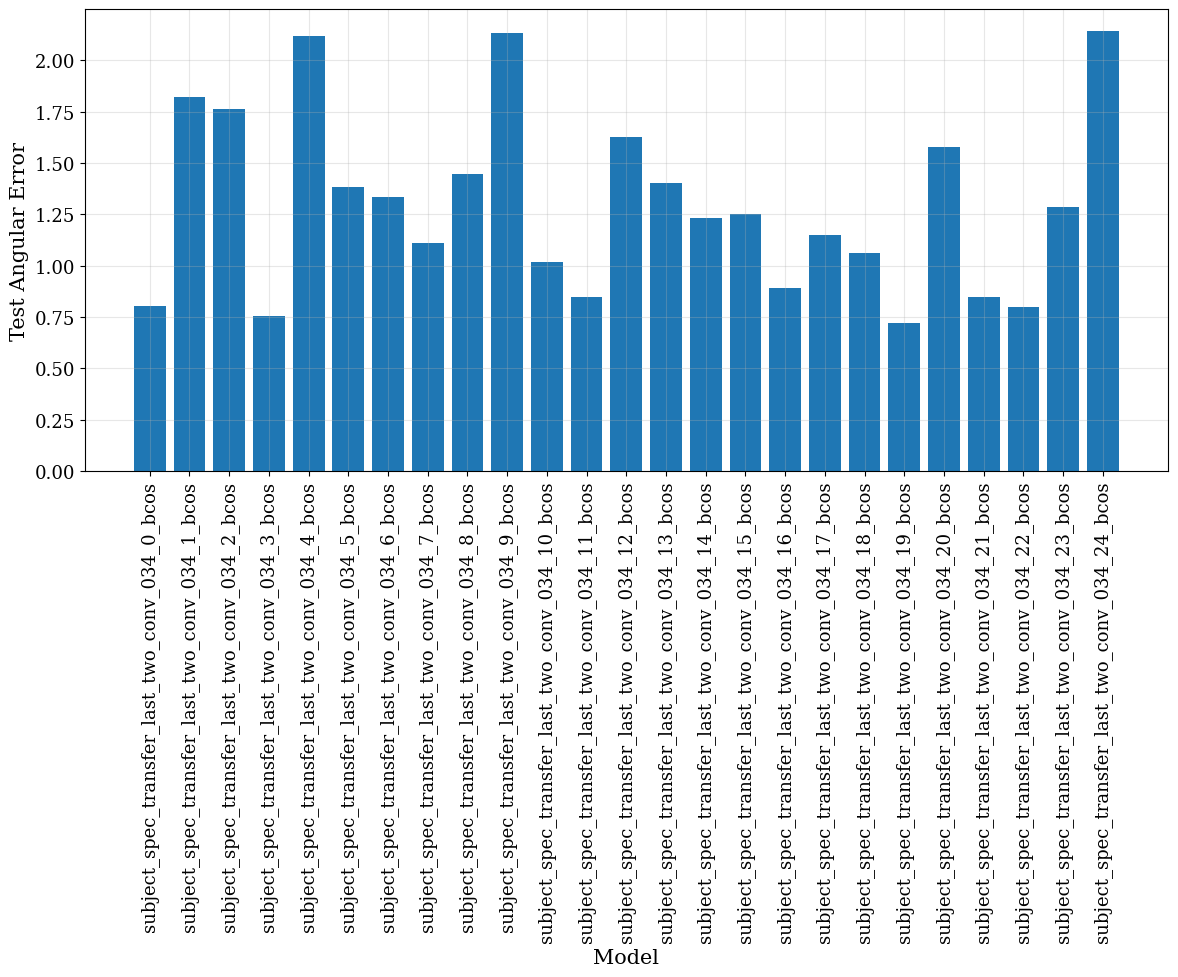

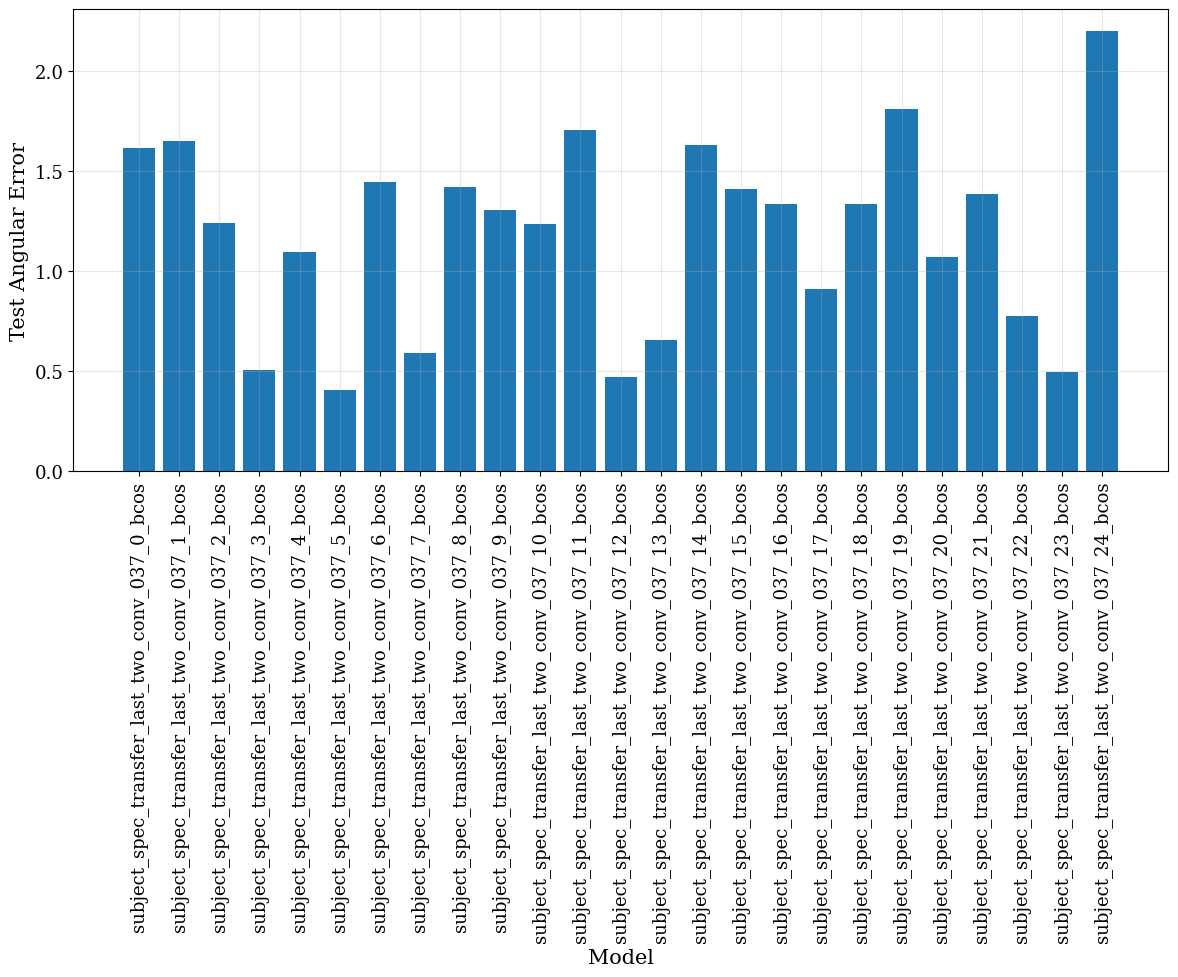

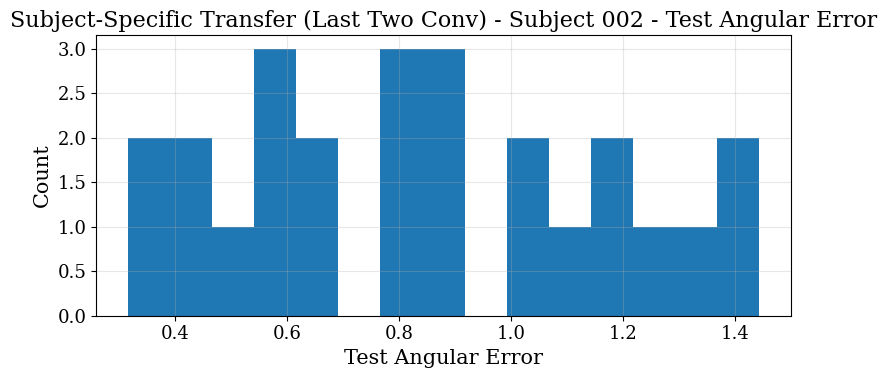

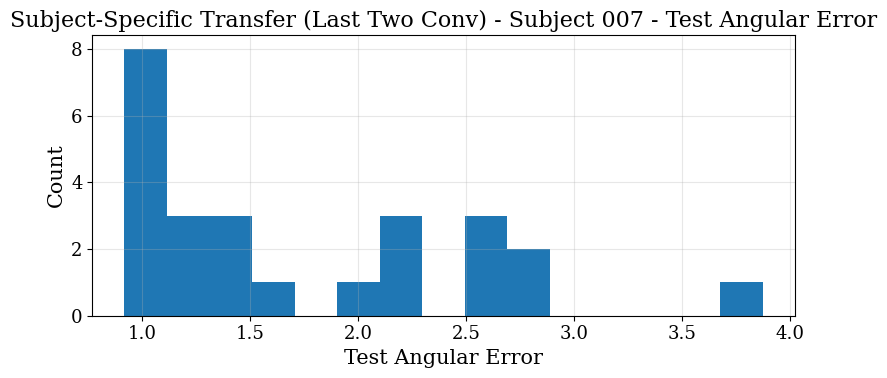

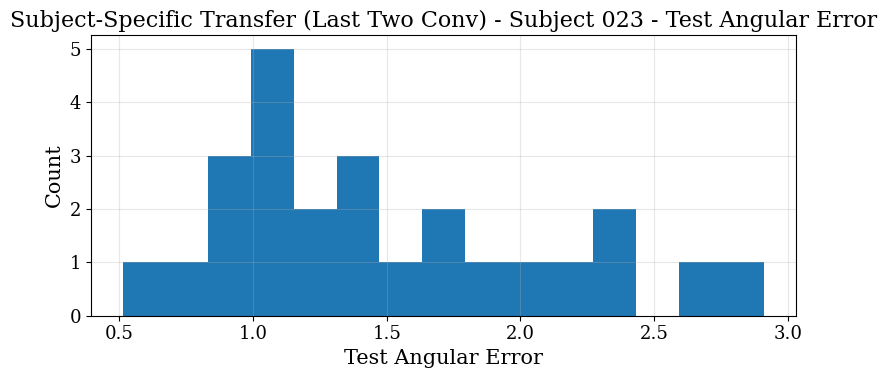

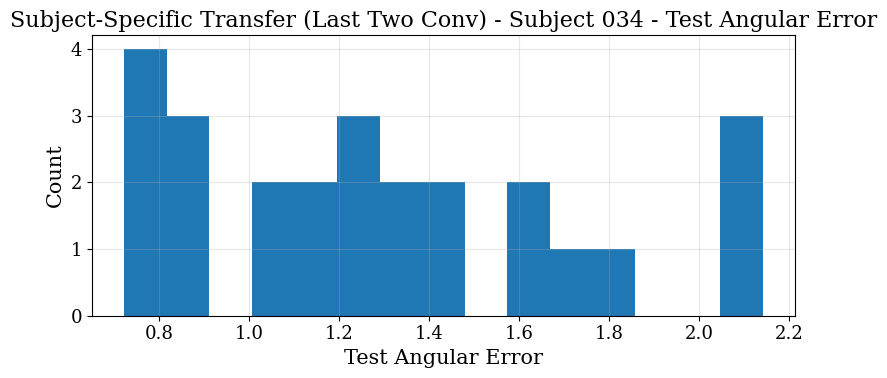

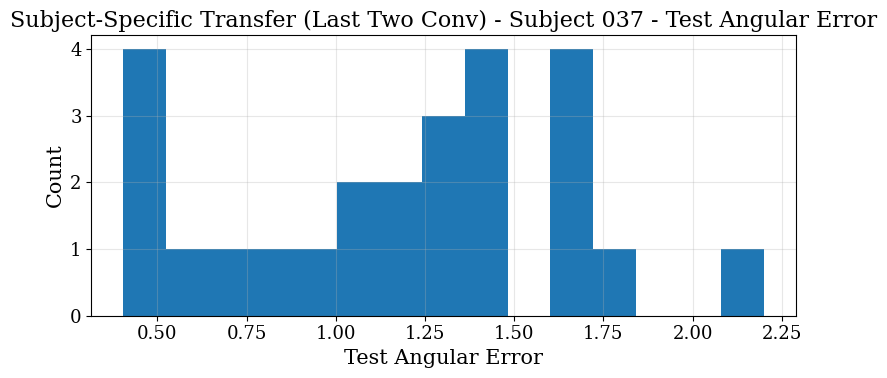

<Figure size 800x500 with 0 Axes>

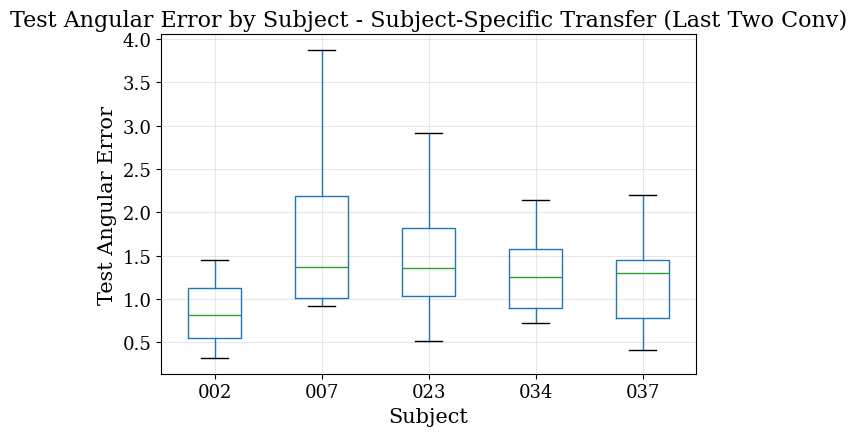

In [9]:
#show_subject_specific_tables(df_transfer_last_2_conv, EXPERIMENT_NAME)
plot_subject_specific_model_performance(df_transfer_last_2_conv, EXPERIMENT_NAME)
plot_subject_specific_error_distribution(df_transfer_last_2_conv, EXPERIMENT_NAME)
plot_subject_specific_boxplots(df_transfer_last_2_conv, EXPERIMENT_NAME)

<br/>

## **Experiment Comparison**

In [10]:
# Runtime
runtime_dfs = {
    "gen_loto_bcos": df_loto,
    "subject_spec_scratch_bcos": df_scratch,
    "subject_spec_transfer_last_two_con_bcos": df_transfer_last_2_conv,
}

for name, df in runtime_dfs.items():
    minutes = df["runtime_sec"].sum() / 60
    print(f"Runtime {name}: {minutes:.1f} min")

Runtime gen_loto_bcos: 466.4 min
Runtime subject_spec_scratch_bcos: 56.4 min
Runtime subject_spec_transfer_last_two_con_bcos: 50.1 min


In [11]:
df_transfer_last_2_conv["experiment_type"] = "transfer_last_2_conv"

df_all = pd.concat(
    [
        df_loto,
        df_scratch,
        df_transfer_last_2_conv,
    ],
    ignore_index=True
)

print(df_all.shape)
df_all.head()

(275, 18)


,model_name,model_path,pretrained_weights,experiment_type,subject_spec_id,held_out_subject,held_out_target,init_mode,n_train,n_val,n_test,best_epoch,best_val_loss,test_loss,test_ang_error,runtime_sec,stopped_early,transfer_mode
0,gen_loto_bcos_0,results\models\gen_loto_bcos_0.pth,NaN,general_loto_bcos,NaN,NaN,0,scratch,92562,1543,2316,38,2.279186,2.382934,2.382934,1470.887534,False,NaN
1,gen_loto_bcos_1,results\models\gen_loto_bcos_1.pth,NaN,general_loto_bcos,NaN,NaN,1,scratch,92574,1538,2309,13,3.279470,3.327747,3.327747,713.317545,True,NaN
2,gen_loto_bcos_2,results\models\gen_loto_bcos_2.pth,NaN,general_loto_bcos,NaN,NaN,2,scratch,92546,1550,2325,5,3.602421,3.503336,3.503336,426.297248,True,NaN
3,gen_loto_bcos_3,results\models\gen_loto_bcos_3.pth,NaN,general_loto_bcos,NaN,NaN,3,scratch,92556,1546,2319,23,2.063104,2.051302,2.051302,1070.417215,True,NaN
4,gen_loto_bcos_4,results\models\gen_loto_bcos_4.pth,NaN,general_loto_bcos,NaN,NaN,4,scratch,92521,1560,2340,24,2.708938,2.834560,2.834560,1106.079653,True,NaN


In [12]:
# Summary statistics per experiment
summary = (
    df_all.groupby("experiment_type")["test_ang_error"]
    .agg(
        n_models="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .round(3)
    #.sort_values("mean")
)

display(summary)

,n_models,mean,median,std,min,max
experiment_type,,,,,,
general_loto_bcos,25,2.241,2.071,0.607,1.447,3.679
subject_spec_scratch_bcos,125,9.077,8.865,4.571,0.363,17.710
transfer_last_2_conv,125,1.306,1.227,0.625,0.315,3.875


<br/>